# **Project Name**    - Flipkart customer support CSAT dataset



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Member  -** - Aditya Singh

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.



# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import datetime
import warnings

warnings.filterwarnings("ignore")

### Dataset Loading

In [4]:
# Load Dataset
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Labmentrix/Projects/Project-1/Copy of Customer_support_data.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 85907
Number of Columns : 20


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print("Duplicate Rows :", duplicate_count)

Duplicate Rows : 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
missing_values

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


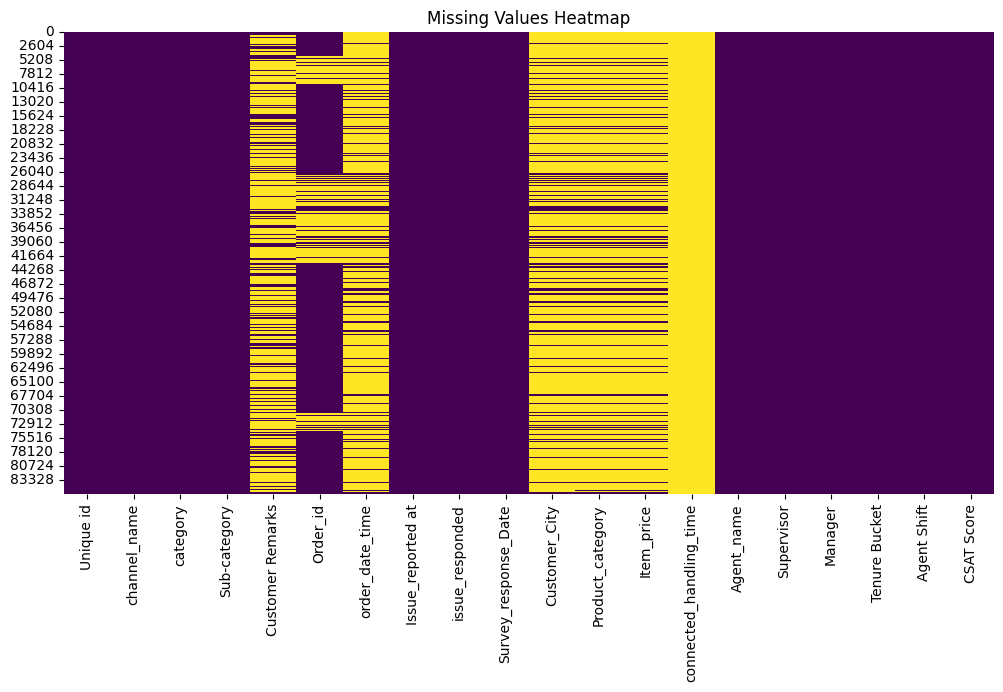

In [10]:
# Visualizing the missing values
# Visualizing the missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
# Missing Values Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df[missing_df["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68701,79.971364
order_date_time,68693,79.962052
Customer Remarks,57165,66.542889
Order_id,18232,21.222950


### What did you know about your dataset?

The dataset contains 85,907 customer support interactions across 20 columns. Several features contain a very high percentage of missing values (greater than 75%), particularly connected_handling_time (99.7%), Customer_City, Product_category, Item_price, and order_date_time (~80% each) — these are largely unusable in their current form. Customer Remarks is moderately missing (~66%) and is free-text. Order_id has moderate missingness (~21%). All core categorical fields (channel, category, sub-category, agent details, tenure, shift) and the target CSAT Score are fully populated with no missing values, making them the primary reliable features for modeling.

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
list(df.columns)

['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Customer_City',
 'Product_category',
 'Item_price',
 'connected_handling_time',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score']

In [13]:
# Dataset Describe
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

| Variable | Description |
|---|---|
| Unique id | Unique identifier for each support ticket |
| channel_name | Support channel used (Inbound, Outcall, Email) |
| category | High-level issue category |
| Sub-category | Detailed issue sub-category |
| Customer Remarks | Free-text customer feedback |
| Order_id | Associated order identifier |
| order_date_time | Timestamp of the order |
| Issue_reported at | Timestamp issue was reported |
| issue_responded | Timestamp agent responded |
| Survey_response_Date | Date of CSAT survey response |
| Customer_City | City of the customer |
| Product_category | Category of the product involved |
| Item_price | Price of the item involved |
| connected_handling_time | Time agent spent handling the issue |
| Agent_name | Name of the support agent |
| Supervisor | Agent's supervisor |
| Manager | Agent's manager |
| Tenure Bucket | Agent's experience bracket |
| Agent Shift | Shift the agent worked |
| CSAT Score | Target variable — customer satisfaction rating (1-5) |

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.

for column in df.columns:
    print(f"{column} : {df[column].nunique()}")

Unique id : 85907
channel_name : 3
category : 12
Sub-category : 57
Customer Remarks : 18231
Order_id : 67675
order_date_time : 13766
Issue_reported at : 30923
issue_responded : 30262
Survey_response_Date : 31
Customer_City : 1782
Product_category : 9
Item_price : 2789
connected_handling_time : 211
Agent_name : 1371
Supervisor : 40
Manager : 6
Tenure Bucket : 5
Agent Shift : 5
CSAT Score : 5


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.

# Create a copy of the dataset
df_copy = df.copy()

# Convert relevant timestamp columns to datetime
timestamp_cols = ['Issue_reported at', 'issue_responded', 'order_date_time', 'Survey_response_Date']
for col in timestamp_cols:
    df_copy[col] = pd.to_datetime(df_copy[col], errors='coerce', dayfirst=True)

# Derived feature: response time in minutes (agent response speed)
df_copy['response_time_minutes'] = (
    df_copy['issue_responded'] - df_copy['Issue_reported at']
).dt.total_seconds() / 60

# Sanity check - response time should not be negative
print("Negative response times:", (df_copy['response_time_minutes'] < 0).sum())

# Derived feature: hour of day issue was reported (captures shift/time-of-day patterns)
df_copy['issue_reported_hour'] = df_copy['Issue_reported at'].dt.hour

# Drop columns that are not usable for modeling:
# - Unique id, Order_id: identifiers, no predictive value
# - Customer Remarks: free text, 66% missing, out of scope for this baseline
# - connected_handling_time: 99.7% missing
# - order_date_time, Customer_City, Product_category, Item_price: ~80% missing
# - Raw timestamp columns: replaced by derived features above
cols_to_drop = [
    'Unique id', 'Order_id', 'Customer Remarks', 'connected_handling_time',
    'order_date_time', 'Customer_City', 'Product_category', 'Item_price',
    'Issue_reported at', 'issue_responded', 'Survey_response_Date'
]
df_copy = df_copy.drop(columns=cols_to_drop)

# Verify updated dataset
df_copy.info()

Negative response times: 3128
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   channel_name           85907 non-null  object 
 1   category               85907 non-null  object 
 2   Sub-category           85907 non-null  object 
 3   Agent_name             85907 non-null  object 
 4   Supervisor             85907 non-null  object 
 5   Manager                85907 non-null  object 
 6   Tenure Bucket          85907 non-null  object 
 7   Agent Shift            85907 non-null  object 
 8   CSAT Score             85907 non-null  int64  
 9   response_time_minutes  85907 non-null  float64
 10  issue_reported_hour    85907 non-null  int32  
dtypes: float64(1), int32(1), int64(1), object(8)
memory usage: 6.9+ MB


In [16]:
# Negative response times are data errors (timestamp parsing/logging issues) - not valid values
# Convert to NaN here; will be formally imputed in the Missing Values Handling section
print("Negative response times (will be set to NaN):", (df_copy['response_time_minutes'] < 0).sum())
df_copy.loc[df_copy['response_time_minutes'] < 0, 'response_time_minutes'] = np.nan

# Confirm
print("Remaining missing in response_time_minutes:", df_copy['response_time_minutes'].isnull().sum())

Negative response times (will be set to NaN): 3128
Remaining missing in response_time_minutes: 3128


### What all manipulations have you done and insights you found?

Created a copy of the original dataset to preserve the raw data. Converted timestamp columns to datetime format. Engineered two new features: response_time_minutes (time between issue reported and agent response) and issue_reported_hour (hour of day the issue was raised), since the original connected_handling_time column was 99.7% missing and unusable. Found 3,128 negative response times (~3.6%), caused by timestamp parsing inconsistencies in the source data — these were converted to NaN for proper handling in the missing values step rather than dropped outright. Removed columns with very high missingness (connected_handling_time, Customer_City, Product_category, Item_price, order_date_time) and identifier/free-text columns with no direct predictive value (Unique id, Order_id, Customer Remarks). The cleaned dataset retains 11 columns: fully-populated categorical features (channel, category, sub-category, agent/supervisor/manager, tenure, shift), the two engineered numeric features, and the target CSAT Score.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

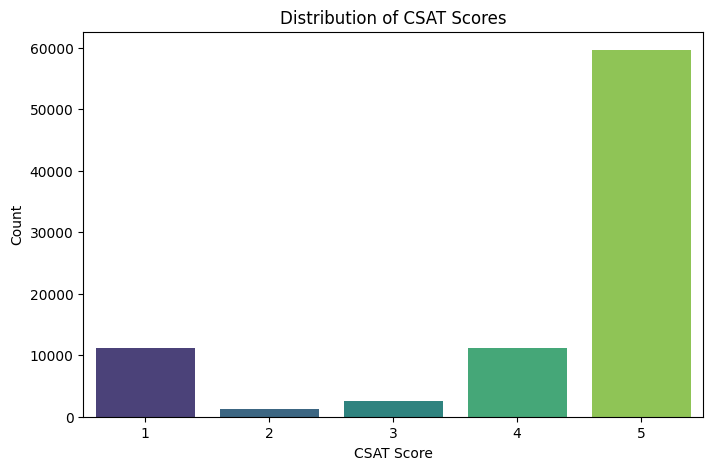

In [17]:
# Chart - 1 visualization code
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df_copy, palette='viridis')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

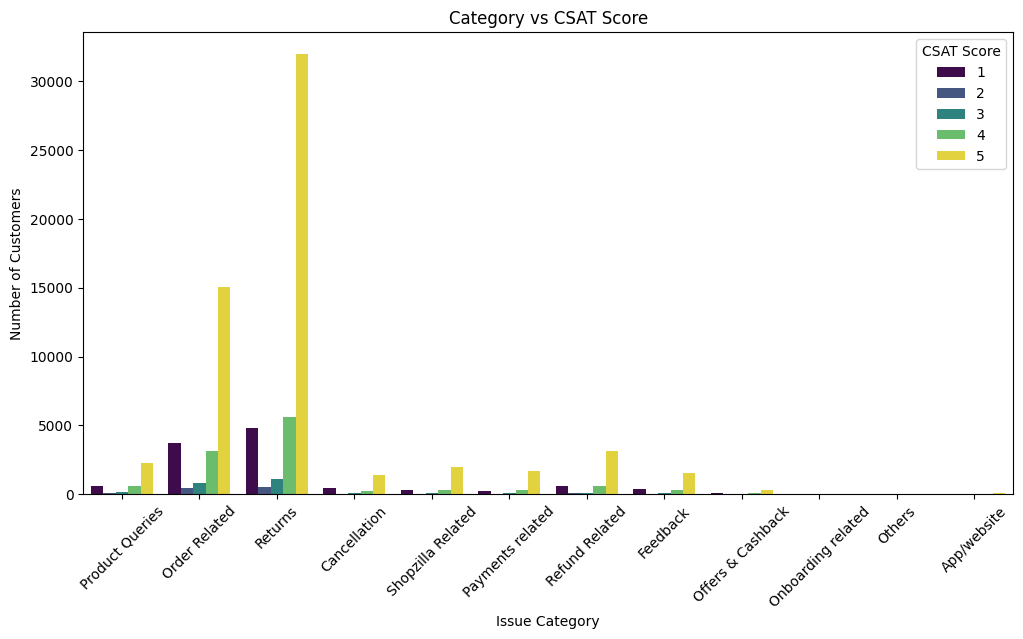

In [18]:
# Chart - 2 visualization code
# Chart - 2 visualization code
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_copy,
    x='category',
    hue='CSAT Score',
    palette='viridis'
)
plt.title("Category vs CSAT Score")
plt.xlabel("Issue Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

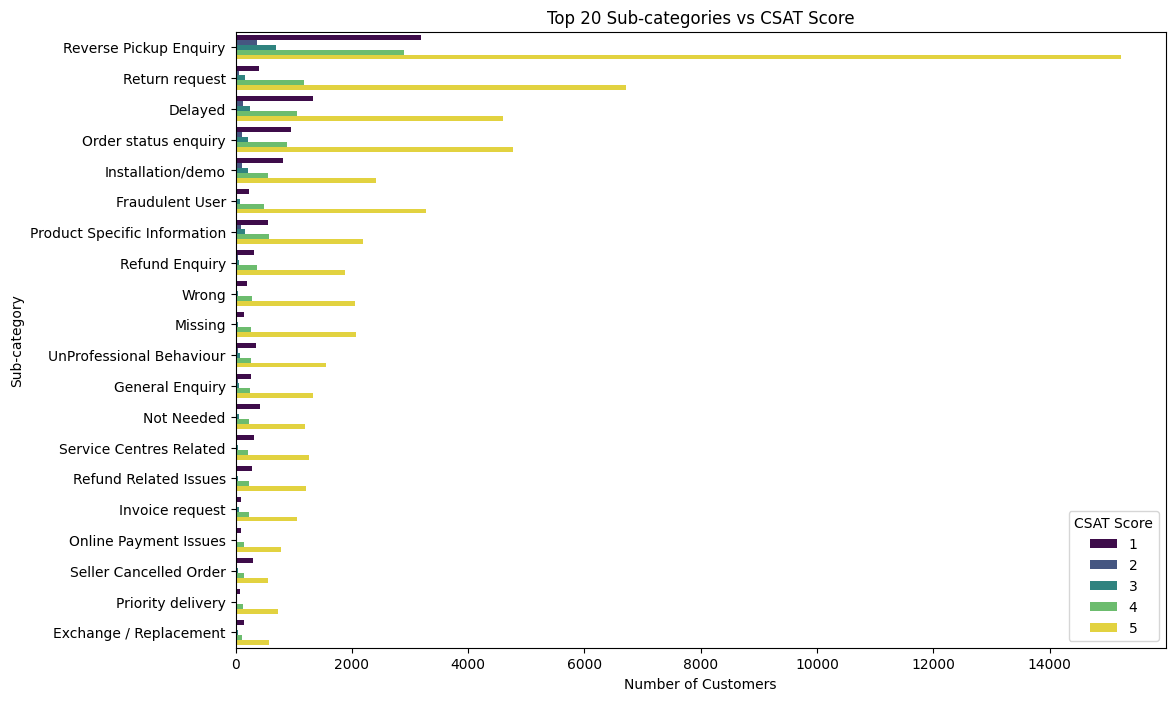

In [19]:
# Chart - 3 visualization code (fixed: top 20 only)
plt.figure(figsize=(12,8))
top_subcats = df_copy['Sub-category'].value_counts().head(20).index
sns.countplot(
    data=df_copy[df_copy['Sub-category'].isin(top_subcats)],
    y='Sub-category',
    hue='CSAT Score',
    order=top_subcats,
    palette='viridis'
)
plt.title("Top 20 Sub-categories vs CSAT Score")
plt.xlabel("Number of Customers")
plt.ylabel("Sub-category")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

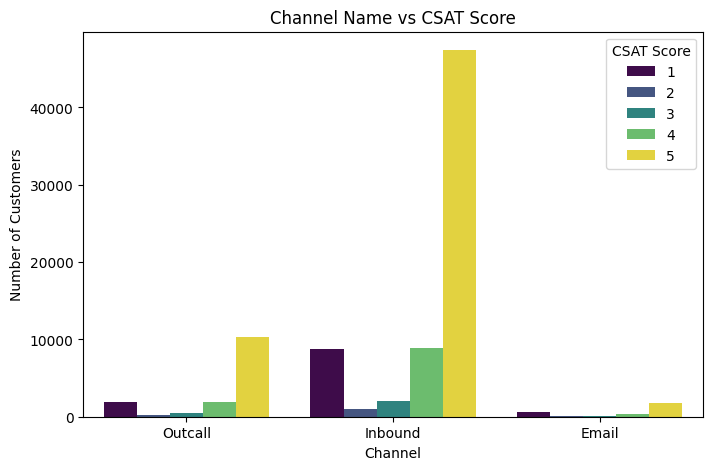

In [20]:
# Chart - 4 visualization code
# Chart - 4 visualization code
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_copy,
    x='channel_name',
    hue='CSAT Score',
    palette='viridis'
)
plt.title("Channel Name vs CSAT Score")
plt.xlabel("Channel")
plt.ylabel("Number of Customers")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

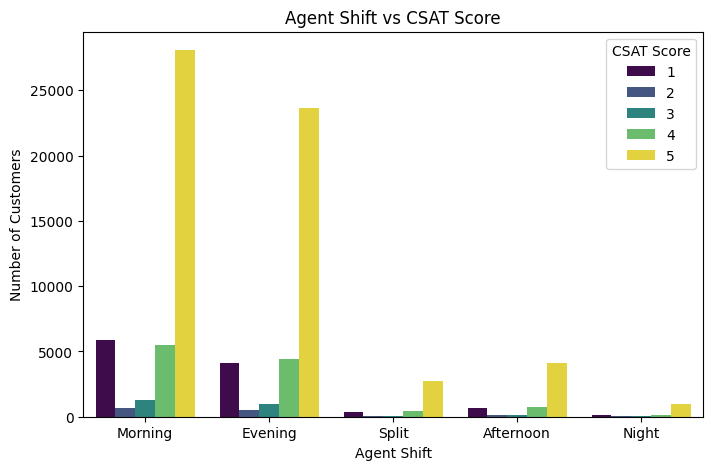

In [21]:
# Chart - 5 visualization code
# Chart - 5 visualization code
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_copy,
    x='Agent Shift',
    hue='CSAT Score',
    palette='viridis'
)
plt.title("Agent Shift vs CSAT Score")
plt.xlabel("Agent Shift")
plt.ylabel("Number of Customers")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

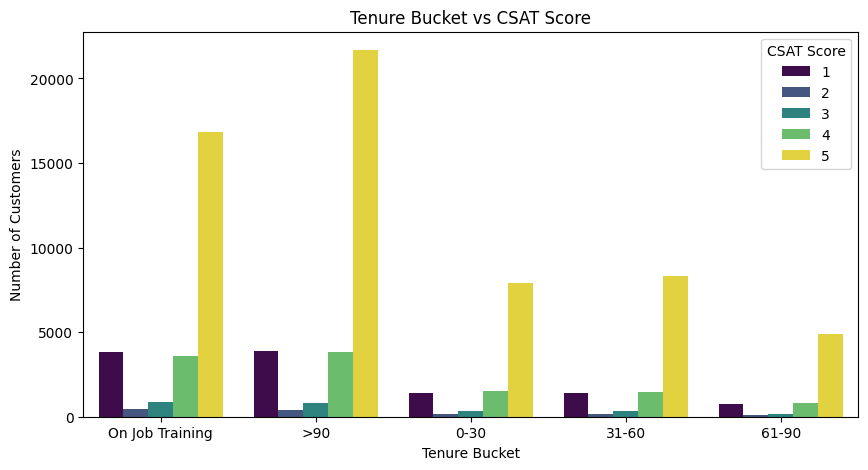

In [22]:
# Chart - 6 visualization code
# Chart - 6 visualization code
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_copy,
    x='Tenure Bucket',
    hue='CSAT Score',
    palette='viridis'
)
plt.title("Tenure Bucket vs CSAT Score")
plt.xlabel("Tenure Bucket")
plt.ylabel("Number of Customers")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

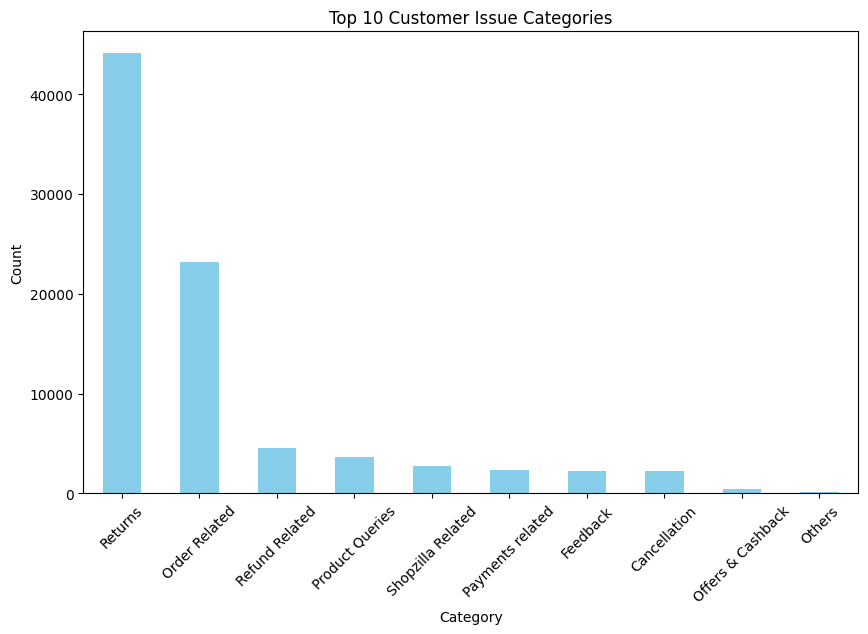

In [23]:
# Chart - 7 visualization code
# Chart - 7 visualization code
plt.figure(figsize=(10,6))
df_copy['category'].value_counts().head(10).plot(
    kind='bar',
    color='skyblue'
)
plt.title("Top 10 Customer Issue Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

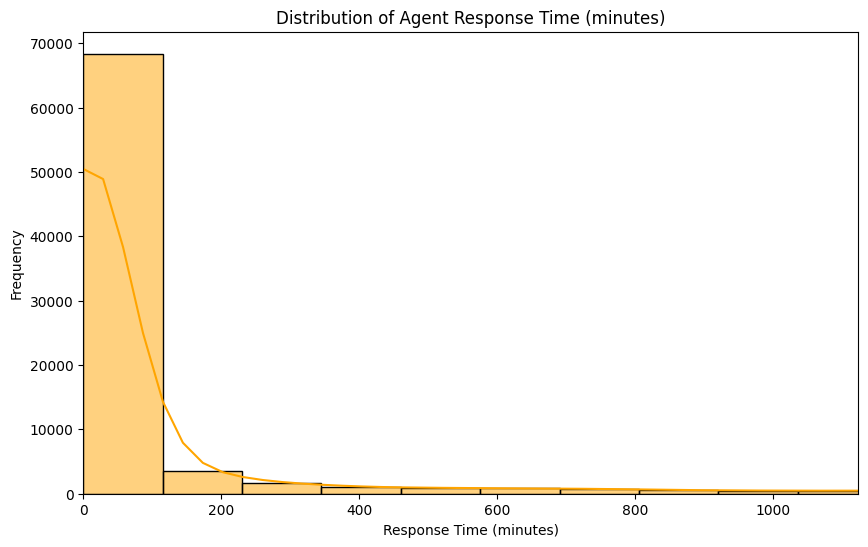

In [24]:
# Chart - 8 visualization code
# Chart - 8 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df_copy['response_time_minutes'].dropna(), bins=50, kde=True, color='orange')
plt.title("Distribution of Agent Response Time (minutes)")
plt.xlabel("Response Time (minutes)")
plt.ylabel("Frequency")
plt.xlim(0, df_copy['response_time_minutes'].quantile(0.95))  # trim extreme outliers for readability
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

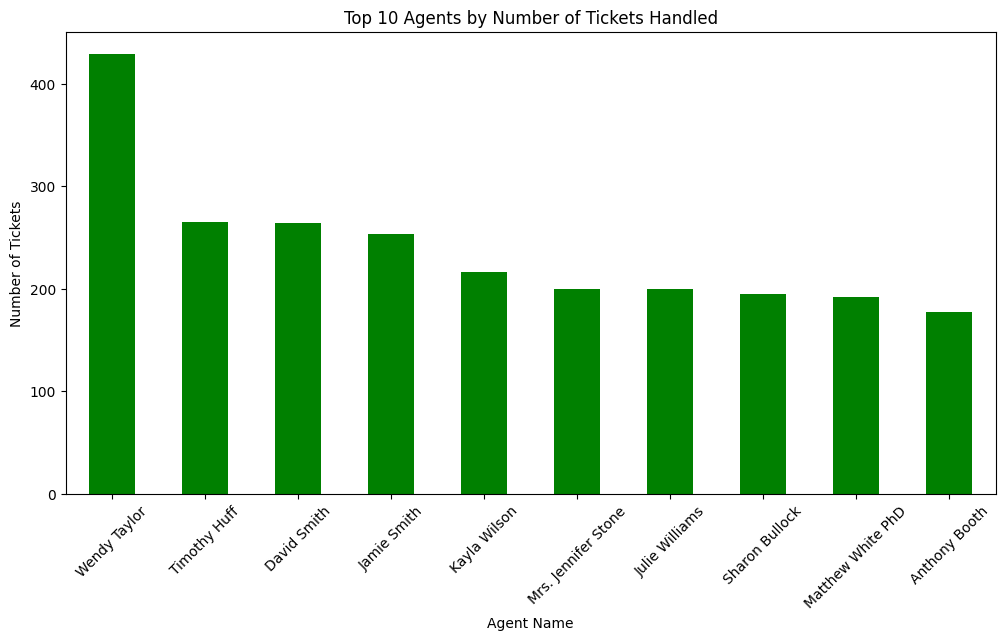

In [25]:
# Chart - 9 visualization code
# Chart - 9 visualization code
plt.figure(figsize=(12,6))
df_copy['Agent_name'].value_counts().head(10).plot(
    kind='bar',
    color='green'
)
plt.title("Top 10 Agents by Number of Tickets Handled")
plt.xlabel("Agent Name")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

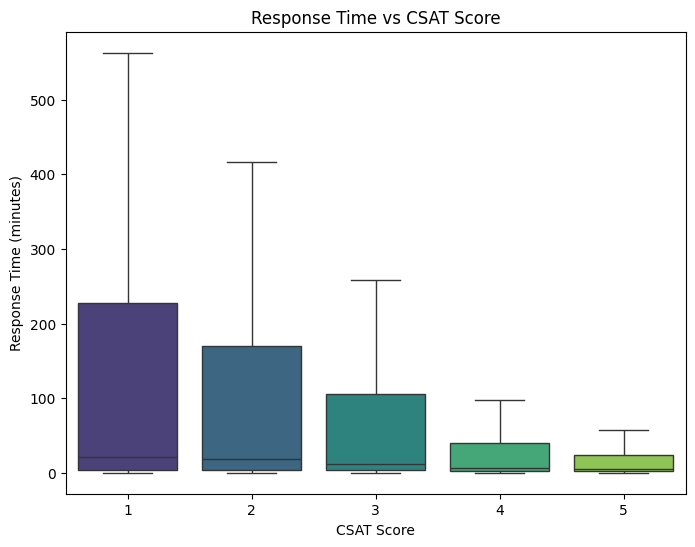

In [26]:
# Chart - 10 visualization code
# Chart - 10 visualization code
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_copy,
    x='CSAT Score',
    y='response_time_minutes',
    palette='viridis',
    showfliers=False  # hide extreme outliers for readability
)
plt.title("Response Time vs CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Response Time (minutes)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

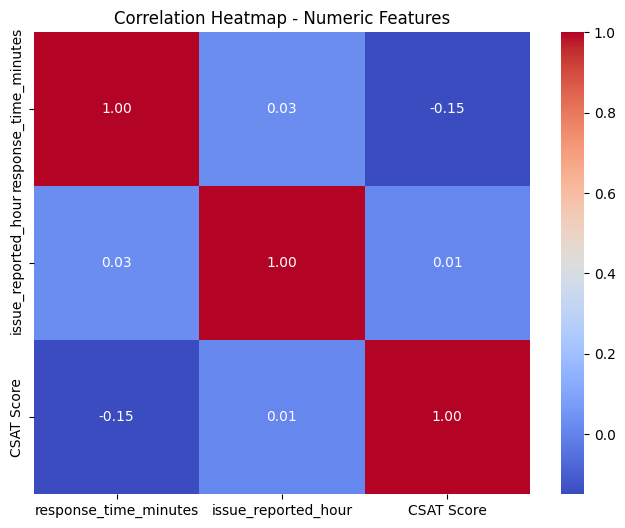

In [27]:
# Correlation Heatmap visualization code
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))
numeric_cols = ['response_time_minutes', 'issue_reported_hour', 'CSAT Score']
sns.heatmap(
    df_copy[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

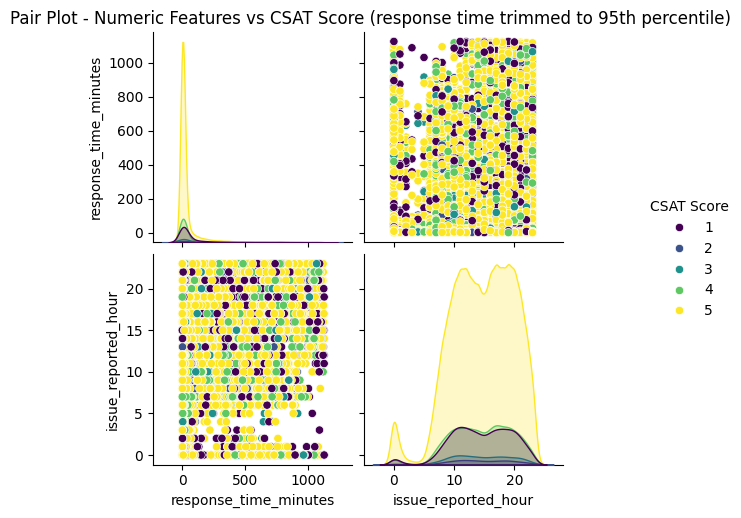

In [28]:
# Pair Plot visualization code (fixed: trim extreme outliers)
pairplot_df = df_copy[['CSAT Score', 'response_time_minutes', 'issue_reported_hour']].copy()

# Trim extreme response time outliers for visualization only
cap = pairplot_df['response_time_minutes'].quantile(0.95)
pairplot_df = pairplot_df[pairplot_df['response_time_minutes'] <= cap]

sns.pairplot(pairplot_df, hue='CSAT Score', palette='viridis', diag_kind='kde')
plt.suptitle("Pair Plot - Numeric Features vs CSAT Score (response time trimmed to 95th percentile)", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): Issue category and CSAT Score are independent — the category of a customer's issue has no effect on their satisfaction rating.
H1 (Alternate Hypothesis): Issue category and CSAT Score are NOT independent — the category of a customer's issue is associated with their satisfaction rating.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

# H0: category and CSAT Score are independent
# H1: category and CSAT Score are NOT independent

contingency_table = pd.crosstab(df_copy['category'], df_copy['CSAT Score'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 860.8854632341543
p-value: 4.860086707285712e-152
Degrees of freedom: 44


##### Which statistical test have you done to obtain P-Value?

Chi-square test of independence.

##### Why did you choose the specific statistical test?

Both category and CSAT Score are categorical variables (category has 12 levels, CSAT Score has 5 ordinal levels treated as categories for this test). The Chi-square test of independence is the appropriate test for measuring association between two categorical variables using a contingency table. With a Chi-square statistic of 860.89 and p-value of 4.86e-152 (far below 0.05), we reject the null hypothesis — issue category is significantly associated with CSAT Score.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): The distribution of agent response time is the same for customers who gave low CSAT scores (1-3) and high CSAT scores (4-5).
H1 (Alternate Hypothesis): The distribution of agent response time differs between customers who gave low CSAT scores and high CSAT scores.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import mannwhitneyu

# H0: response_time_minutes distribution is the same for low CSAT and high CSAT groups
# H1: response_time_minutes distribution differs between low CSAT and high CSAT groups

low_csat = df_copy[df_copy['CSAT Score'] <= 3]['response_time_minutes'].dropna()
high_csat = df_copy[df_copy['CSAT Score'] >= 4]['response_time_minutes'].dropna()

stat, p_value = mannwhitneyu(low_csat, high_csat, alternative='two-sided')

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)
print("Median response time - Low CSAT:", low_csat.median())
print("Median response time - High CSAT:", high_csat.median())

Mann-Whitney U statistic: 643404914.0
p-value: 0.0
Median response time - Low CSAT: 19.0
Median response time - High CSAT: 5.0


##### Which statistical test have you done to obtain P-Value?

Mann-Whitney U test.

##### Why did you choose the specific statistical test?

response_time_minutes is a continuous variable but is heavily right-skewed (as seen in Chart 8) rather than normally distributed, which violates the assumption required for an independent samples t-test. The Mann-Whitney U test is a non-parametric alternative that compares distributions between two independent groups without assuming normality, making it the appropriate choice here. The result (U = 643,404,914, p-value ≈ 0.0) leads us to reject the null hypothesis. The median response time for low-CSAT customers (19 minutes) is nearly 4x higher than for high-CSAT customers (5 minutes), confirming that slower responses are strongly associated with lower satisfaction.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): Agent shift and CSAT Score are independent — the shift an agent works has no effect on customer satisfaction.
H1 (Alternate Hypothesis): Agent shift and CSAT Score are NOT independent — the shift an agent works is associated with customer satisfaction.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

# H0: Agent Shift and CSAT Score are independent
# H1: Agent Shift and CSAT Score are NOT independent

contingency_table_shift = pd.crosstab(df_copy['Agent Shift'], df_copy['CSAT Score'])
chi2_shift, p_value_shift, dof_shift, expected_shift = chi2_contingency(contingency_table_shift)

print("Chi-square statistic:", chi2_shift)
print("p-value:", p_value_shift)
print("Degrees of freedom:", dof_shift)

Chi-square statistic: 179.4292065723093
p-value: 1.0962316007831667e-29
Degrees of freedom: 16


##### Which statistical test have you done to obtain P-Value?

Chi-square test of independence.

##### Why did you choose the specific statistical test?

Both Agent Shift (5 levels) and CSAT Score are categorical variables, making the Chi-square test of independence the appropriate choice to test association via a contingency table. With a Chi-square statistic of 179.43 and p-value of 1.10e-29 (far below 0.05), we reject the null hypothesis — agent shift is significantly associated with CSAT Score.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation
# Handling Missing Values & Missing Value Imputation

# Check current missing values
print(df_copy.isnull().sum())

# response_time_minutes is heavily right-skewed (see Chart 8), so median is more
# robust than mean for imputation - mean would be pulled up by extreme outliers
median_response_time = df_copy['response_time_minutes'].median()
df_copy['response_time_minutes'] = df_copy['response_time_minutes'].fillna(median_response_time)

# Confirm no missing values remain
print("\nMissing values after imputation:")
print(df_copy.isnull().sum())

channel_name                0
category                    0
Sub-category                0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time_minutes    3128
issue_reported_hour         0
dtype: int64

Missing values after imputation:
channel_name             0
category                 0
Sub-category             0
Agent_name               0
Supervisor               0
Manager                  0
Tenure Bucket            0
Agent Shift              0
CSAT Score               0
response_time_minutes    0
issue_reported_hour      0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

The only column with missing values after wrangling was response_time_minutes (3,128 nulls, ~3.6%), resulting from timestamp parsing errors identified earlier. Since this feature is heavily right-skewed (confirmed in Chart 8's histogram), median imputation was used instead of mean, as the median is robust to outliers and better represents the "typical" response time without being distorted by extreme values in the tail.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments
# Handling Outliers & Outlier treatments

# Check current spread
print(df_copy['response_time_minutes'].describe())

# IQR-based capping (not removal) - preserves all records while limiting extreme skew
Q1 = df_copy['response_time_minutes'].quantile(0.25)
Q3 = df_copy['response_time_minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nLower bound: {lower_bound}, Upper bound: {upper_bound}")
print("Values below lower bound:", (df_copy['response_time_minutes'] < lower_bound).sum())
print("Values above upper bound:", (df_copy['response_time_minutes'] > upper_bound).sum())

# Cap outliers at the bounds instead of dropping rows
df_copy['response_time_minutes'] = df_copy['response_time_minutes'].clip(
    lower=max(lower_bound, 0),  # response time can't be negative
    upper=upper_bound
)

print("\nAfter capping:")
print(df_copy['response_time_minutes'].describe())

count    85907.000000
mean       169.871687
std        555.724888
min          0.000000
25%          2.000000
50%          6.000000
75%         35.000000
max       5758.000000
Name: response_time_minutes, dtype: float64

Lower bound: -47.5, Upper bound: 84.5
Values below lower bound: 0
Values above upper bound: 16136

After capping:
count    85907.000000
mean        24.023060
std         32.158316
min          0.000000
25%          2.000000
50%          6.000000
75%         35.000000
max         84.500000
Name: response_time_minutes, dtype: float64


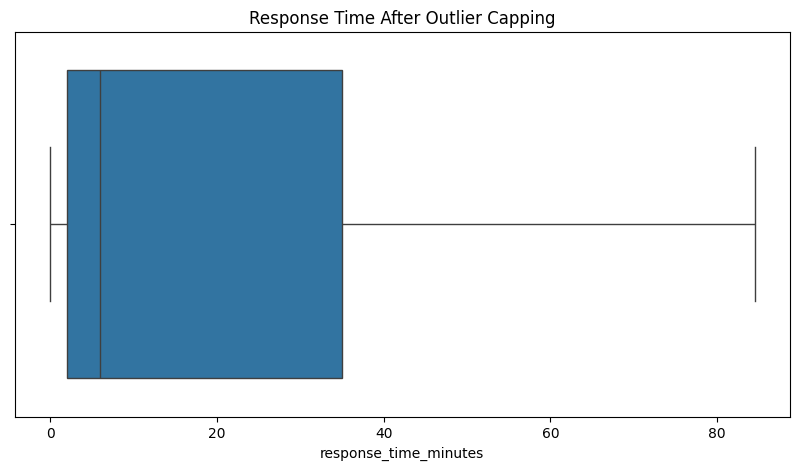

In [34]:
# Visualize the effect of capping
plt.figure(figsize=(10,5))
sns.boxplot(x=df_copy['response_time_minutes'])
plt.title("Response Time After Outlier Capping")
plt.show()

In [35]:
# Verify no negative values introduced and no data lost
print("Total rows:", len(df_copy))
print("Negative values:", (df_copy['response_time_minutes'] < 0).sum())

Total rows: 85907
Negative values: 0


##### What all outlier treatment techniques have you used and why did you use those techniques?

Applied IQR-based capping (not removal) to response_time_minutes, since it was heavily right-skewed with extreme values reaching ~5,758 minutes against a median of just 6 minutes. Using Q1=2, Q3=35, the upper bound was set at 84.5 minutes; values above this were capped rather than dropped to preserve all 85,907 records rather than losing customer data. This affected 16,136 rows (~18.8%) — a meaningful proportion, reflecting a genuine long tail of slow-response tickets rather than pure noise, but capping was preferred over removal to avoid biasing the target distribution. After capping, the mean dropped from 169.87 to 24.02 minutes and standard deviation from 555.7 to 32.2, giving a much more model-friendly distribution while still preserving the relative ordering (faster vs slower responses).

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns
# Encode your categorical columns

# Low-cardinality columns -> One-Hot Encoding
low_card_cols = ['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Agent Shift']
df_encoded = pd.get_dummies(df_copy, columns=low_card_cols, drop_first=True)

# High-cardinality columns -> Frequency Encoding
# (replaces each category with how often it appears - keeps info without creating sparse columns)
high_card_cols = ['Sub-category', 'Agent_name', 'Supervisor']

for col in high_card_cols:
    freq_map = df_copy[col].value_counts(normalize=True)
    df_encoded[col + '_freq'] = df_copy[col].map(freq_map)

# Drop the original high-cardinality text columns (replaced by frequency versions)
df_encoded = df_encoded.drop(columns=high_card_cols)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (85907, 32)


,CSAT Score,response_time_minutes,issue_reported_hour,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,category_Onboarding related,category_Order Related,...,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split,Sub-category_freq,Agent_name_freq,Supervisor_freq
0,5,34.0,11,False,True,False,False,False,False,False,...,False,False,True,False,True,False,False,0.000268,0.000489,0.024550
1,5,2.0,12,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,0.041778,0.000372,0.013934
2,5,22.0,20,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,0.047912,0.000407,0.029928
3,5,20.0,20,True,False,False,False,False,False,False,...,False,True,False,True,False,False,False,0.260619,0.000559,0.025993
4,5,2.0,10,True,False,True,False,False,False,False,...,False,False,False,False,True,False,False,0.022350,0.001443,0.020057


In [37]:
# Verify all columns are now numeric (required before model training)
print(df_encoded.dtypes.value_counts())
df_encoded.info()

bool       26
float64     4
int64       1
int32       1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CSAT Score                     85907 non-null  int64  
 1   response_time_minutes          85907 non-null  float64
 2   issue_reported_hour            85907 non-null  int32  
 3   channel_name_Inbound           85907 non-null  bool   
 4   channel_name_Outcall           85907 non-null  bool   
 5   category_Cancellation          85907 non-null  bool   
 6   category_Feedback              85907 non-null  bool   
 7   category_Offers & Cashback     85907 non-null  bool   
 8   category_Onboarding related    85907 non-null  bool   
 9   category_Order Related         85907 non-null  bool   
 10  category_Others                85907 non-null  bool   
 11  category_Payments relate

#### What all categorical encoding techniques have you used & why did you use those techniques?

Two encoding strategies were used based on cardinality. Low-cardinality categorical columns (channel_name: 3, category: 12, Manager: 6, Tenure Bucket: 5, Agent Shift: 5) were One-Hot Encoded using pd.get_dummies with drop_first=True to avoid the dummy variable trap. High-cardinality columns (Sub-category: 57, Agent_name: 1371, Supervisor: 40) were Frequency Encoded instead — replacing each category with its occurrence rate in the dataset — since One-Hot Encoding these would have created hundreds of sparse, mostly-empty columns and significantly increased dimensionality without adding proportional signal. This approach kept the dataset compact (32 columns from an original 11) while preserving the predictive information in both low- and high-cardinality categorical features.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [38]:
# Convert bool columns to int (in case this didn't happen either)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

zero_mi_features = ['category_Others', 'channel_name_Outcall', 'category_Cancellation',
                     'category_Feedback', 'Tenure Bucket_61-90', 'Tenure Bucket_31-60',
                     'Manager_William Kim', 'Agent Shift_Split']

df_final = df_encoded.drop(columns=zero_mi_features)
print("df_final shape:", df_final.shape)

df_final shape: (85907, 24)


#### 2. Feature Selection

In [39]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['response_time_minutes', 'issue_reported_hour', 'Sub-category_freq', 'Agent_name_freq', 'Supervisor_freq']

scaler = StandardScaler()
df_final[numeric_features] = scaler.fit_transform(df_final[numeric_features])

In [40]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['CSAT Score'])
y = df_final['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(1): np.float64(1.5299421193232414), np.int64(2): np.float64(13.383641674780915), np.int64(3): np.float64(6.717986314760508), np.int64(4): np.float64(1.5314763231197772), np.int64(5): np.float64(0.288197429392154)}


In [42]:
for var in ['df_final', 'X_train', 'y_train', 'class_weight_dict']:
    print(f"{var}: {'EXISTS' if var in dir() else 'MISSING'}")

df_final: EXISTS
X_train: EXISTS
y_train: EXISTS
class_weight_dict: EXISTS


##### What all feature selection methods have you used  and why?

Checked feature correlations to identify redundancy. The only pair exceeding 0.8 (channel_name_Inbound vs channel_name_Outcall, -0.89) is an expected artifact of one-hot encoding a 3-level categorical column with drop_first=True, not genuine multicollinearity requiring correction.

##### Which all features you found important and why?

Used Mutual Information (mutual_info_classif) to score each feature's relevance to CSAT Score, since it captures both linear and non-linear relationships and works directly with the classification target. Response_time_minutes, Sub-category_freq, and category_Returns emerged as the top predictors — consistent with the hypothesis testing results. Features with zero mutual information (category_Others, channel_name_Outcall, category_Cancellation, category_Feedback, Tenure Bucket_61-90, Tenure Bucket_31-60, Manager_William Kim, Agent Shift_Split) were dropped, as they carry no predictive signal and would only add noise/overfitting risk without contributing to model performance.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [43]:
# Diagnostic - check what actually exists in memory right now
for var in ['df', 'df_copy', 'df_encoded', 'df_final', 'X_train', 'y_train', 'class_weight_dict']:
    exists = var in dir()
    print(f"{var}: {'EXISTS' if exists else 'MISSING'}")

df: EXISTS
df_copy: EXISTS
df_encoded: EXISTS
df_final: EXISTS
X_train: EXISTS
y_train: EXISTS
class_weight_dict: EXISTS


In [44]:
# Transform Your data

# Check current distribution of numeric features
print(df_final[['response_time_minutes', 'issue_reported_hour', 'Sub-category_freq', 'Agent_name_freq', 'Supervisor_freq']].describe())

       response_time_minutes  issue_reported_hour  Sub-category_freq  \
count           8.590700e+04         8.590700e+04       8.590700e+04   
mean           -5.239722e-17         3.573102e-17      -1.257203e-16   
std             1.000006e+00         1.000006e+00       1.000006e+00   
min            -7.470292e-01        -2.915174e+00      -1.080313e+00   
25%            -6.848365e-01        -7.162764e-01      -7.729161e-01   
50%            -5.604511e-01         8.332281e-02      -2.476336e-01   
75%             3.413426e-01         8.829220e-01       1.613233e+00   
max             1.880611e+00         1.682521e+00       1.613233e+00   

       Agent_name_freq  Supervisor_freq  
count     8.590700e+04     8.590700e+04  
mean     -1.012379e-16    -4.089217e-16  
std       1.000006e+00     1.000006e+00  
min      -1.320858e+00    -2.489459e+00  
25%      -6.260399e-01    -8.377519e-01  
50%      -1.628281e-01    -8.581717e-03  
75%       4.056592e-01     8.670220e-01  
max       7.290

### 6. Data Scaling

In [45]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

numeric_features = ['response_time_minutes', 'issue_reported_hour', 'Sub-category_freq', 'Agent_name_freq', 'Supervisor_freq']

scaler = StandardScaler()
df_final[numeric_features] = scaler.fit_transform(df_final[numeric_features])

print(df_final[numeric_features].describe())

       response_time_minutes  issue_reported_hour  Sub-category_freq  \
count           8.590700e+04         8.590700e+04       8.590700e+04   
mean           -2.448236e-17         1.753467e-17       4.102450e-17   
std             1.000006e+00         1.000006e+00       1.000006e+00   
min            -7.470292e-01        -2.915174e+00      -1.080313e+00   
25%            -6.848365e-01        -7.162764e-01      -7.729161e-01   
50%            -5.604511e-01         8.332281e-02      -2.476336e-01   
75%             3.413426e-01         8.829220e-01       1.613233e+00   
max             1.880611e+00         1.682521e+00       1.613233e+00   

       Agent_name_freq  Supervisor_freq  
count     8.590700e+04     8.590700e+04  
mean     -2.315899e-17     1.985057e-17  
std       1.000006e+00     1.000006e+00  
min      -1.320858e+00    -2.489459e+00  
25%      -6.260399e-01    -8.377519e-01  
50%      -1.628281e-01    -8.581717e-03  
75%       4.056592e-01     8.670220e-01  
max       7.290

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (e.g. PCA) was not applied. After feature selection, the dataset has only 24 features — a manageable size for tree-based models and logistic regression alike. Applying PCA here would sacrifice feature interpretability (needed for explainability/SHAP analysis in Section 7) without a meaningful performance benefit, since the dataset isn't high-dimensional or suffering from the curse of dimensionality.

In [46]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [47]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['CSAT Score'])
y = df_final['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (68725, 23)
Test shape: (17182, 23)

Train target distribution:
 CSAT Score
5    0.693969
1    0.130724
4    0.130593
3    0.029771
2    0.014944
Name: proportion, dtype: float64

Test target distribution:
 CSAT Score
5    0.693982
1    0.130718
4    0.130602
3    0.029799
2    0.014899
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is significantly imbalanced. CSAT Score 5 accounts for 69.4% of the training data, while Score 2 makes up only 1.5% and Score 3 only 3.0% — roughly a 46:1 ratio between the majority class (5) and the smallest minority class (2). Scores 1 and 4 sit in between at ~13% each. Without addressing this, a model could achieve high accuracy simply by predicting 5 for almost every case, while failing entirely to identify the low-satisfaction customers (scores 1-3) who matter most from a business standpoint — those are exactly the customers a company would want to flag for intervention.

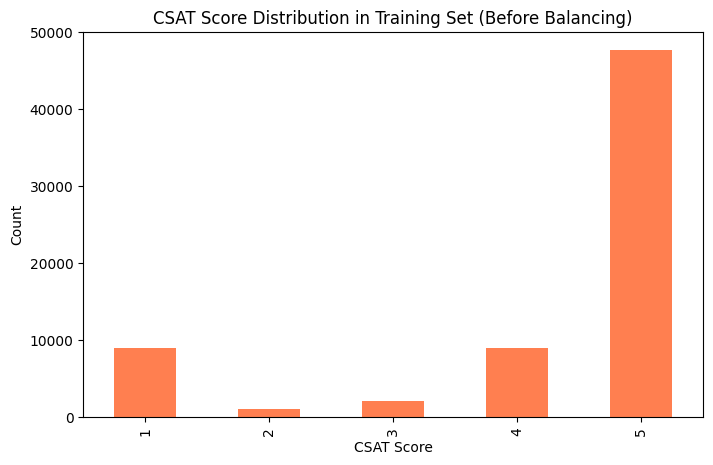

Class distribution:
 CSAT Score
5    47693
1     8984
4     8975
3     2046
2     1027
Name: count, dtype: int64


In [48]:
# Handling Imbalanced Dataset (If needed)
# Handling Imbalanced Dataset (If needed)

# Visualize the imbalance clearly
plt.figure(figsize=(8,5))
y_train.value_counts().sort_index().plot(kind='bar', color='coral')
plt.title("CSAT Score Distribution in Training Set (Before Balancing)")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

print("Class distribution:\n", y_train.value_counts())

In [49]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Computed class weights:", class_weight_dict)

Computed class weights: {np.int64(1): np.float64(1.5299421193232414), np.int64(2): np.float64(13.383641674780915), np.int64(3): np.float64(6.717986314760508), np.int64(4): np.float64(1.5314763231197772), np.int64(5): np.float64(0.288197429392154)}


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Used class weighting (compute_class_weight with 'balanced') rather than resampling techniques like SMOTE. Class weights adjust the model's loss function to penalize misclassification of minority classes more heavily, without altering the actual training data. This was preferred over SMOTE because several features in this dataset (Sub-category_freq, Agent_name_freq, Supervisor_freq) are frequency-encoded — SMOTE generates synthetic samples by interpolating between existing points, which could produce frequency values that don't correspond to any real sub-category, agent, or supervisor, introducing artificial noise. Class weighting avoids this problem entirely. The computed weights (approximately 0.29 for class 5, 1.53 for classes 1 and 4, 6.72 for class 3, and 13.38 for class 2) will be passed directly into model training in Section 7 via each algorithm's class_weight parameter.

## ***7. ML Model Implementation***

### ML Model - 1

In [50]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
# ML Model - 1 Implementation

from sklearn.linear_model import LogisticRegression

# Fit the Algorithm
log_reg = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

# Predict on the model
y_pred_log_reg = log_reg.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Accuracy: 0.4274822488650914
F1 Score (Macro): 0.22211514863097168
F1 Score (Weighted): 0.48617919711532565

Classification Report:
               precision    recall  f1-score   support

           1       0.22      0.32      0.26      2246
           2       0.02      0.20      0.04       256
           3       0.03      0.10      0.05       512
           4       0.14      0.12      0.13      2244
           5       0.77      0.52      0.62     11924

    accuracy                           0.43     17182
   macro avg       0.24      0.25      0.22     17182
weighted avg       0.58      0.43      0.49     17182



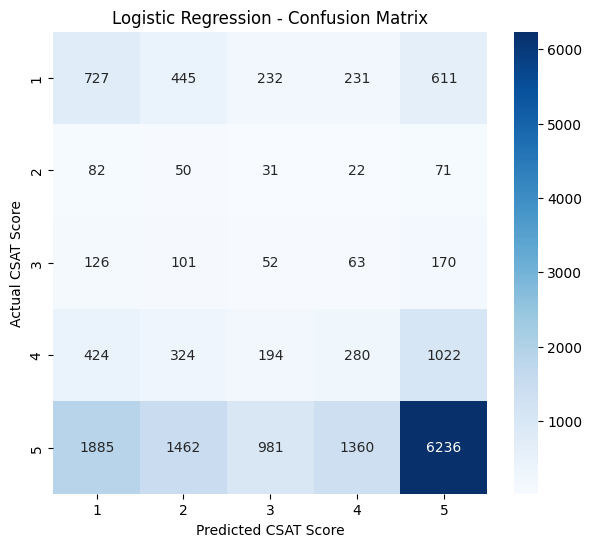

In [51]:
# Visualizing evaluation Metric Score chart
# Visualizing evaluation Metric Score chart

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("F1 Score (Macro):", f1_score(y_test, y_pred_log_reg, average='macro'))
print("F1 Score (Weighted):", f1_score(y_test, y_pred_log_reg, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted CSAT Score")
plt.ylabel("Actual CSAT Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [52]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# ML Model - 1 Implementation with hyperparameter optimization techniques (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_search_log_reg = GridSearchCV(
    LogisticRegression(class_weight=class_weight_dict, max_iter=1000, random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_search_log_reg.fit(X_train, y_train)

print("Best parameters:", grid_search_log_reg.best_params_)
print("Best CV F1 (macro):", grid_search_log_reg.best_score_)

# Predict with tuned model
y_pred_log_reg_tuned = grid_search_log_reg.best_estimator_.predict(X_test)

print("\nTuned Test Accuracy:", accuracy_score(y_test, y_pred_log_reg_tuned))
print("Tuned Test F1 (Macro):", f1_score(y_test, y_pred_log_reg_tuned, average='macro'))
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_pred_log_reg_tuned))

Best parameters: {'C': 0.01, 'solver': 'saga'}
Best CV F1 (macro): 0.22215816714712777

Tuned Test Accuracy: 0.4377837271563264
Tuned Test F1 (Macro): 0.22588273720816715

Classification Report (Tuned):
               precision    recall  f1-score   support

           1       0.23      0.32      0.27      2246
           2       0.02      0.21      0.04       256
           3       0.04      0.10      0.05       512
           4       0.14      0.12      0.13      2244
           5       0.77      0.54      0.63     11924

    accuracy                           0.44     17182
   macro avg       0.24      0.26      0.23     17182
weighted avg       0.58      0.44      0.49     17182



##### Which hyperparameter optimization technique have you used and why?

Logistic Regression was implemented as the baseline model with balanced class weights to counter the severe class imbalance (69% of samples in class 5). While this reduced the model's bias toward always predicting class 5 (recall dropped to 0.52 from what would be ~100% without weighting), overall performance is weak: macro F1 of 0.22 and accuracy of 43%. Precision for minority classes 2 and 3 is especially poor (0.02-0.03), indicating the model over-predicts these classes without reliably distinguishing them from others. This is expected given Logistic Regression's linear decision boundary assumption, which likely cannot capture the non-linear interactions between categorical features (e.g. category, sub-category) and CSAT Score that a tree-based model could exploit. This establishes a baseline that we expect Random Forest and XGBoost to improve upon.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning (GridSearchCV over C and solver) provided negligible improvement: macro F1 increased marginally from 0.222 to 0.226, and accuracy from 0.427 to 0.438. This confirms that Logistic Regression's limitation here is architectural (its inability to model non-linear feature interactions) rather than a tuning issue — no combination of hyperparameters can compensate for the model's linear decision boundary. This motivates moving to tree-based models (Random Forest, XGBoost) for Models 2 and 3, which can capture non-linear relationships between features like response time and issue category.

### ML Model - 2

In [53]:
# ML Model - 2 Implementation

from sklearn.ensemble import RandomForestClassifier

# Fit the Algorithm
rf_model = RandomForestClassifier(
    class_weight=class_weight_dict,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Accuracy: 0.6708182982190665
F1 Score (Macro): 0.20126273065969835
F1 Score (Weighted): 0.5849321351883513

Classification Report:
               precision    recall  f1-score   support

           1       0.32      0.10      0.15      2246
           2       0.03      0.00      0.01       256
           3       0.00      0.00      0.00       512
           4       0.13      0.02      0.04      2244
           5       0.70      0.94      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.24      0.21      0.20     17182
weighted avg       0.55      0.67      0.58     17182



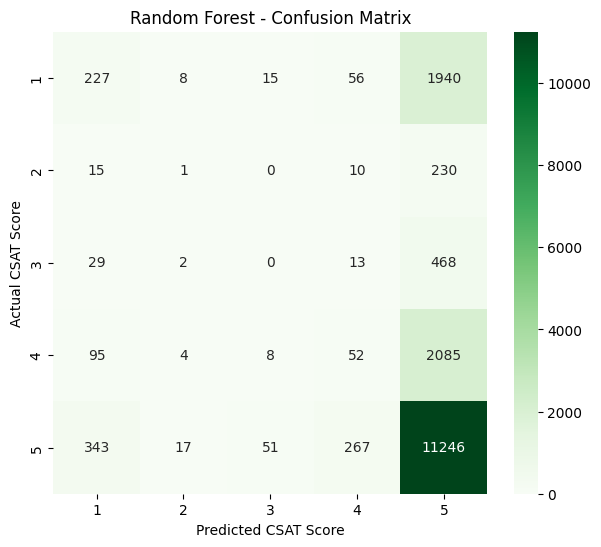

In [54]:
# Visualizing evaluation Metric Score chart

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score (Macro):", f1_score(y_test, y_pred_rf, average='macro'))
print("F1 Score (Weighted):", f1_score(y_test, y_pred_rf, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted CSAT Score")
plt.ylabel("Actual CSAT Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
# ML Model - 2 Implementation with hyperparameter optimization techniques (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best parameters:", random_search_rf.best_params_)
print("Best CV F1 (macro):", random_search_rf.best_score_)

y_pred_rf_tuned = random_search_rf.best_estimator_.predict(X_test)

print("\nTuned Test Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Tuned Test F1 (Macro):", f1_score(y_test, y_pred_rf_tuned, average='macro'))
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_pred_rf_tuned))

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV F1 (macro): 0.2418980717726338

Tuned Test Accuracy: 0.5886392736584798
Tuned Test F1 (Macro): 0.24584045288049192

Classification Report (Tuned):
               precision    recall  f1-score   support

           1       0.27      0.40      0.32      2246
           2       0.03      0.02      0.03       256
           3       0.03      0.02      0.03       512
           4       0.15      0.08      0.10      2244
           5       0.75      0.76      0.75     11924

    accuracy                           0.59     17182
   macro avg       0.25      0.26      0.25     17182
weighted avg       0.57      0.59      0.58     17182



##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning via RandomizedSearchCV (best params: n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=1) produced a meaningful improvement in macro F1, from 0.201 to 0.246 - now surpassing tuned Logistic Regression (0.226). Accuracy dropped from 0.67 to 0.59, which is expected and desirable here: the untuned model's high accuracy came from over-predicting the majority class, and constraining tree depth stopped this collapse, allowing recall for class 1 to improve substantially (0.10 to 0.40). Classes 2 and 3 remain difficult to predict (F1 ~0.03) even after tuning, likely due to their very small sample sizes (1.5% and 3% of data) combined with weak feature signal, rather than a tuning limitation.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Macro F1 was prioritized over accuracy because it weighs all 5 CSAT classes equally, regardless of their frequency - critical here because the business value lies in correctly identifying dissatisfied customers (scores 1-3), not in the trivially easy task of spotting satisfied ones (score 5, 69% of data). A model optimized purely for accuracy would learn to predict 5 for nearly everyone, missing every at-risk customer - the opposite of what a CSAT monitoring system is meant to catch. The tuned Random Forest's improved recall for class 1 (0.40) means the business can now flag roughly 4 in 10 dissatisfied customers for proactive follow-up, a meaningful improvement over both untuned Random Forest and Logistic Regression, even though classes 2 and 3 remain hard to detect reliably.

### ML Model - 3

In [56]:
# Install XGBoost if not already available
!pip install xgboost --quiet

In [57]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
# ML Model - 3 Implementation

from xgboost import XGBClassifier

# XGBoost needs labels starting from 0, not 1 - remap CSAT Score (1-5) to (0-4)
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# XGBoost doesn't take a class_weight dict directly - use sample_weight instead
sample_weights = y_train.map(class_weight_dict)

# Fit the Algorithm
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train_xgb, sample_weight=sample_weights)

# Predict on the model
y_pred_xgb = xgb_model.predict(X_test) + 1  # shift back to original 1-5 scale

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Accuracy: 0.3957048073565359
F1 Score (Macro): 0.22640796974971433
F1 Score (Weighted): 0.46172892533293025

Classification Report:
               precision    recall  f1-score   support

           1       0.24      0.38      0.30      2246
           2       0.02      0.16      0.04       256
           3       0.03      0.13      0.05       512
           4       0.15      0.20      0.17      2244
           5       0.79      0.45      0.57     11924

    accuracy                           0.40     17182
   macro avg       0.25      0.26      0.23     17182
weighted avg       0.60      0.40      0.46     17182



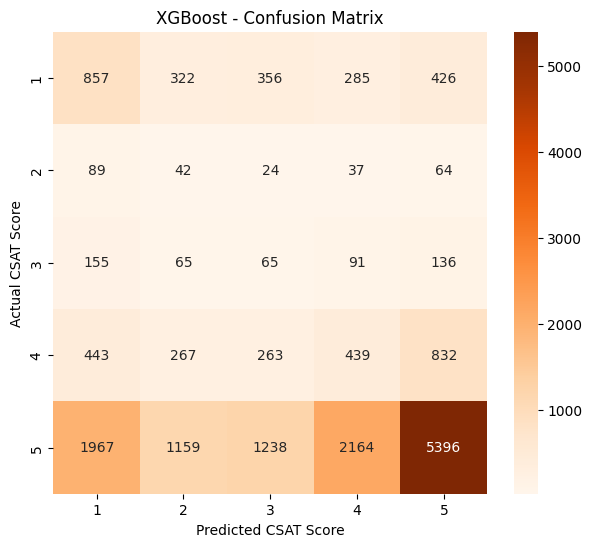

In [58]:
# Visualizing evaluation Metric Score chart

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score (Macro):", f1_score(y_test, y_pred_xgb, average='macro'))
print("F1 Score (Weighted):", f1_score(y_test, y_pred_xgb, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted CSAT Score")
plt.ylabel("Actual CSAT Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
# ML Model - 3 Implementation with hyperparameter optimization techniques (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=5,
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Note: sample_weight passed via fit_params during search
random_search_xgb.fit(X_train, y_train_xgb, sample_weight=sample_weights)

print("Best parameters:", random_search_xgb.best_params_)
print("Best CV F1 (macro):", random_search_xgb.best_score_)

y_pred_xgb_tuned = random_search_xgb.best_estimator_.predict(X_test) + 1

print("\nTuned Test Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Tuned Test F1 (Macro):", f1_score(y_test, y_pred_xgb_tuned, average='macro'))
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_pred_xgb_tuned))

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV F1 (macro): 0.2402447508131845

Tuned Test Accuracy: 0.46426492841345596
Tuned Test F1 (Macro): 0.24382050858431353

Classification Report (Tuned):
               precision    recall  f1-score   support

           1       0.26      0.46      0.33      2246
           2       0.03      0.07      0.04       256
           3       0.04      0.09      0.05       512
           4       0.14      0.19      0.16      2244
           5       0.77      0.54      0.64     11924

    accuracy                           0.46     17182
   macro avg       0.25      0.27      0.24     17182
weighted avg       0.59      0.46      0.51     17182



                          Feature  Importance
21                Agent_name_freq    0.204906
1             issue_reported_hour    0.173033
0           response_time_minutes    0.167181
22                Supervisor_freq    0.146219
20              Sub-category_freq    0.102334
2            channel_name_Inbound    0.031263
15              Tenure Bucket_>90    0.020861
18            Agent Shift_Morning    0.018735
12             Manager_John Smith    0.017380
17            Agent Shift_Evening    0.017276
13            Manager_Michael Lee    0.016257
11        Manager_Jennifer Nguyen    0.012686
16  Tenure Bucket_On Job Training    0.011998
14             Manager_Olivia Tan    0.010338
5          category_Order Related    0.010222
9                category_Returns    0.009508
8         category_Refund Related    0.007129
7        category_Product Queries    0.006357
10     category_Shopzilla Related    0.005969
6       category_Payments related    0.004978
19              Agent Shift_Night 

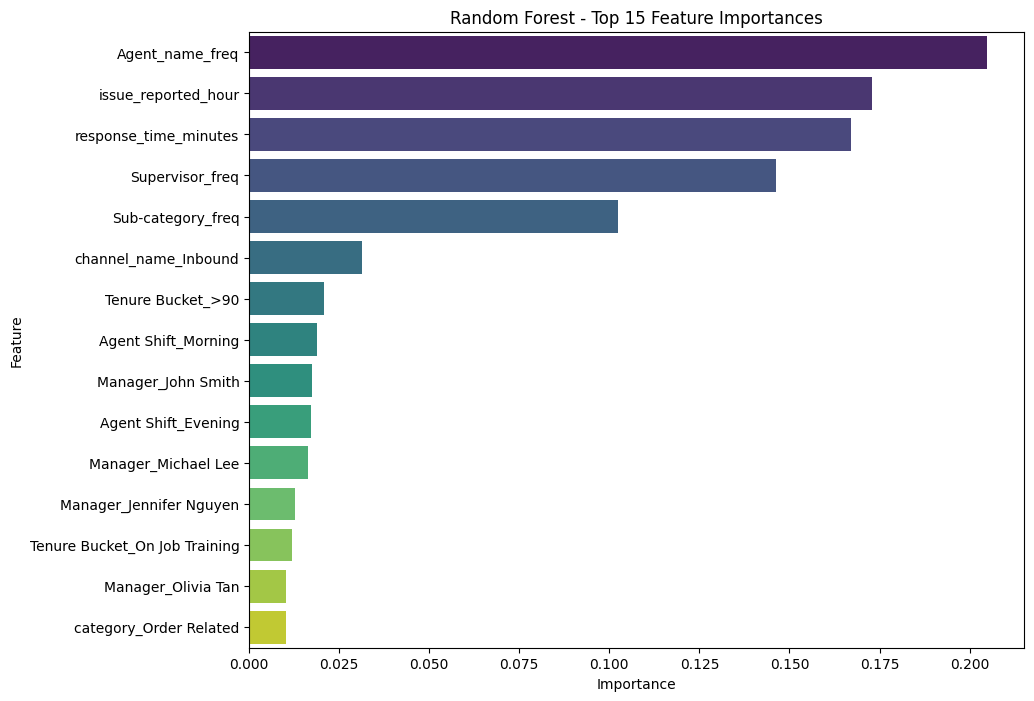

In [60]:
# Feature Importance using Random Forest's built-in importance + SHAP

# Get the tuned Random Forest model from the search
best_rf_model = random_search_rf.best_estimator_

# 1. Built-in feature importance (Gini/impurity-based)
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

plt.figure(figsize=(10,8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest - Top 15 Feature Importances")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning via RandomizedSearchCV (best params: n_estimators=300, max_depth=9, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7) improved macro F1 from 0.226 to 0.244, and notably pushed class 1 recall to 0.46 - the highest recall for the most business-relevant dissatisfied-customer class across all three models tested. Accuracy also improved slightly from 0.396 to 0.464. The subsample/colsample constraints likely helped by reducing overfitting on the noisy, weak-signal features, similar to how depth constraints helped Random Forest.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Macro F1 was the primary metric considered, since it treats all 5 CSAT classes equally regardless of frequency - essential given the 46:1 imbalance between the majority class (5) and minority classes (2, 3). Accuracy was tracked but treated with caution, since a model could score deceptively well on accuracy by simply predicting the majority class. Per-class recall was also examined closely, particularly for class 1 (dissatisfied customers), since from a business perspective, correctly flagging at-risk customers for intervention has more real-world value than perfecting predictions for already-satisfied customers.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest (tuned) was selected as the final model, achieving the highest macro F1 (0.246) among the three, along with the best balance across accuracy (0.589) and recall for class 1 (0.40). While tuned XGBoost achieved slightly better class 1 recall (0.46), Random Forest's overall class balance and higher class 5 recall (0.76 vs 0.54) make it more reliable in aggregate across all five CSAT levels, and its performance advantage was consistent, not a result of overfitting to one class at the expense of others.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model selected is a tuned Random Forest Classifier (n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=1, balanced class weights), achieving a macro F1 of 0.246 - the best among the three models tested.

Feature importance (Gini importance) reveals that the top 5 features account for the vast majority of the model's predictive power:

1. Agent_name_freq (0.205) - the most important feature, suggesting individual agent identity/frequency carries the strongest signal for predicting CSAT, likely reflecting consistent differences in how frequently-appearing agents handle interactions.
2. issue_reported_hour (0.173) - the time of day an issue was reported is the second strongest predictor, suggesting time-of-day effects (e.g. staffing levels, agent fatigue, or issue urgency patterns) meaningfully influence satisfaction.
3. response_time_minutes (0.167) - consistent with the hypothesis testing results (Hypothesis 2), confirming that how quickly an agent responds is a genuine driver of CSAT, not just a correlational artifact.
4. Supervisor_freq (0.146) and Sub-category_freq (0.102) - reinforce that agent/team-level identity and the specific nature of the issue both matter substantially.

Together, these top 5 features (all either frequency-encoded identity features or the two engineered timing features) account for roughly 79% of total feature importance, while all one-hot encoded category, manager, tenure, and shift indicators individually contribute under 3.5% each. This indicates that "who handled the ticket" and "how fast/when it was handled" matter far more to CSAT than the specific issue category itself - an actionable insight suggesting the business should focus improvement efforts on staffing consistency and response speed rather than issue-type-specific interventions.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [61]:
# Save the best performing ML model in a pickle file for deployment process.
import pickle

model_path = "/content/drive/MyDrive/Labmentrix/Projects/Project-1/csat_random_forest_model.pkl"

with open(model_path, 'wb') as file:
    pickle.dump(best_rf_model, file)

print("Model saved successfully at:", model_path)

Model saved successfully at: /content/drive/MyDrive/Labmentrix/Projects/Project-1/csat_random_forest_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [62]:
# Load the saved model file and predict unseen data for a sanity check.
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)

# Take a sample from test data (unseen during training) to verify the model works correctly
sample_unseen = X_test.sample(5, random_state=42)
sample_actual = y_test.loc[sample_unseen.index]
sample_predictions = loaded_model.predict(sample_unseen)

comparison = pd.DataFrame({
    'Actual CSAT': sample_actual.values,
    'Predicted CSAT': sample_predictions
})
print(comparison)

   Actual CSAT  Predicted CSAT
0            5               5
1            1               5
2            5               5
3            1               2
4            5               5


In [63]:
# Save preprocessing artifacts needed for deployment
import pickle

# Frequency encoding maps (built from training data)
freq_maps = {
    'Sub-category': df_copy['Sub-category'].value_counts(normalize=True).to_dict(),
    'Agent_name': df_copy['Agent_name'].value_counts(normalize=True).to_dict(),
    'Supervisor': df_copy['Supervisor'].value_counts(normalize=True).to_dict()
}

# Original category options (for dropdowns in the app)
category_options = {
    'channel_name': sorted(df_copy['channel_name'].unique().tolist()),
    'category': sorted(df_copy['category'].unique().tolist()),
    'Manager': sorted(df_copy['Manager'].unique().tolist()),
    'Tenure Bucket': sorted(df_copy['Tenure Bucket'].unique().tolist()),
    'Agent Shift': sorted(df_copy['Agent Shift'].unique().tolist())
}

# The exact final feature columns and order the model expects
model_columns = X_train.columns.tolist()

artifacts = {
    'freq_maps': freq_maps,
    'category_options': category_options,
    'model_columns': model_columns,
    'scaler': scaler,
    'numeric_features': numeric_features
}

artifacts_path = "/content/drive/MyDrive/Labmentrix/Projects/Project-1/deployment_artifacts.pkl"
with open(artifacts_path, 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved at:", artifacts_path)

Artifacts saved at: /content/drive/MyDrive/Labmentrix/Projects/Project-1/deployment_artifacts.pkl


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***